In [1]:
import cv2

cap = cv2.VideoCapture(0)
cv2.namedWindow('Interactive Systems: Towards AR Tracking')
while True:

    # 1. read each frame from the camera (if necessary resize the image)
    #    and extract the SIFT features using OpenCV methods
    #    Note: use the gray image - so you need to convert the image
    # 2. draw the keypoints using cv2.drawKeypoints
    #    There are several flags for visualization - e.g. DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS

    # close the window and application by pressing a key

    # YOUR CODE HERE
    ret, frame = cap.read()
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    sift = cv2.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(gray, None)
    img_with_keypoints = cv2.drawKeypoints(gray, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    cv2.imshow('Interactive Systems: Towards AR Tracking', img_with_keypoints)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


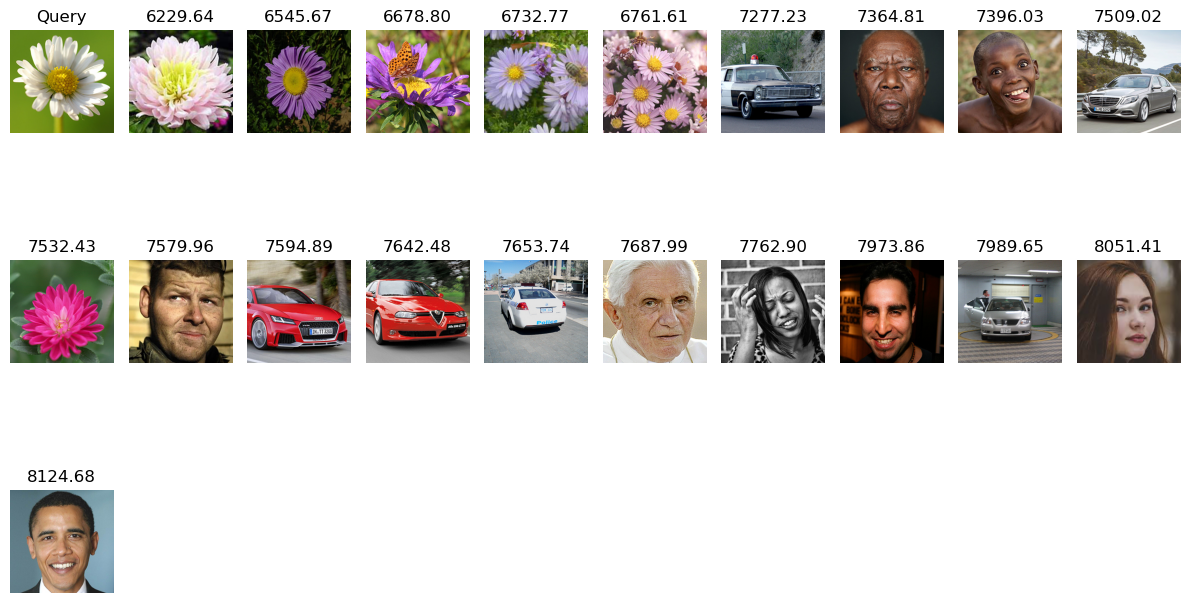

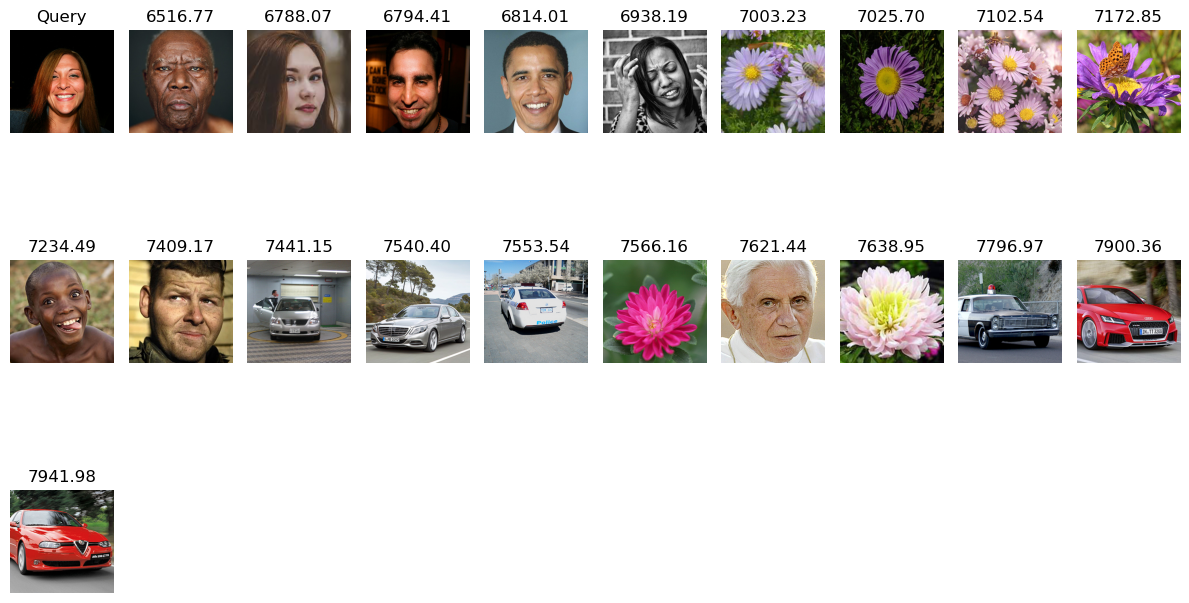

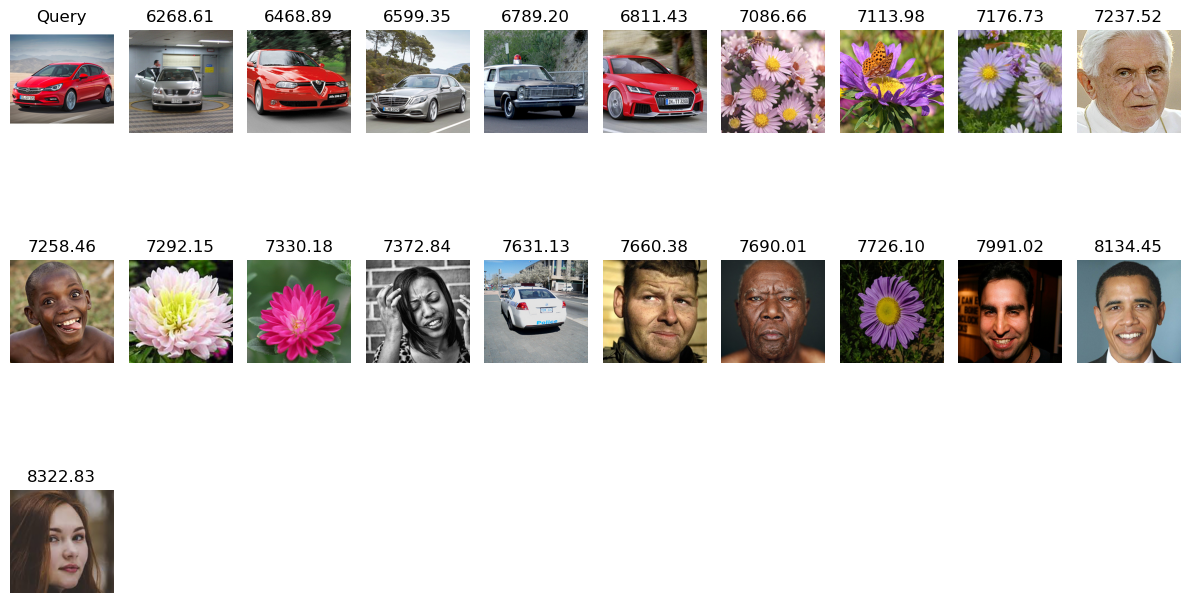

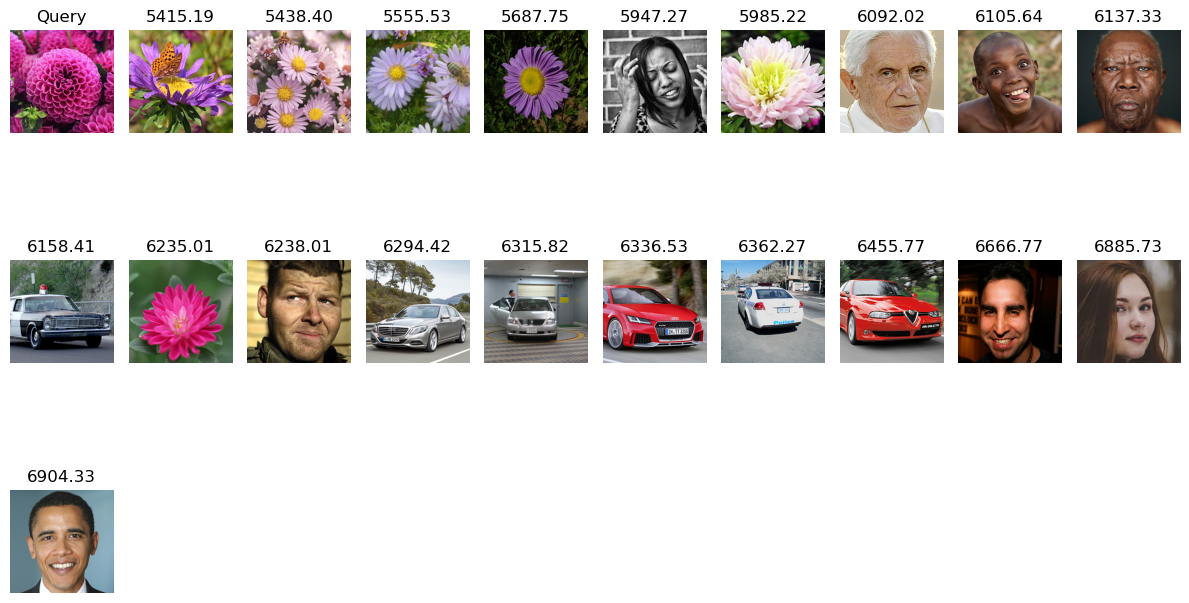

In [62]:
import cv2
import glob
import numpy as np
from queue import PriorityQueue
import matplotlib.pyplot as plt

def distance(a, b):
    return np.linalg.norm(a - b)

def create_keypoints(w, h, step=16):
    keypoints = []
    keypointSize = 11
    for y in range(step, h - step, step):
        for x in range(step, w - step, step):
            keypoints.append(cv2.KeyPoint(float(x), float(y), keypointSize))
    return keypoints

def show_results(query_path, results, k=20):
    query_img = cv2.cvtColor(cv2.imread(query_path), cv2.COLOR_BGR2RGB)
    num_results = min(k, len(results))
    images_per_row = 10
    total_images = 1 + num_results
    rows = int(np.ceil(total_images / images_per_row))

    plt.figure(figsize=(12, 2.5 * rows))
    plt.subplot(rows, images_per_row, 1)
    plt.imshow(query_img)
    plt.title("Query")
    plt.axis("off")

    for i in range(num_results):
        dist, img_path = results[i]
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        plt.subplot(rows, images_per_row, i + 2)
        plt.imshow(img)
        plt.title(f"{dist:.2f}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

TARGET_W, TARGET_H = 256, 256
sift = cv2.SIFT_create()
keypoints = create_keypoints(TARGET_W, TARGET_H, step=16)

images = glob.glob('./images/db/train/*/*.jpg')
descriptors = []

for image_path in images:
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    img = cv2.resize(img, (TARGET_W, TARGET_H)) 
    _, des = sift.compute(img, keypoints)
    if des is not None:
        descriptors.append((des, image_path))

# Query
for query in glob.glob('./images/db/test/*.jpg'):
    query_img = cv2.imread(query, cv2.IMREAD_GRAYSCALE)
    if query_img is None:
        continue
    query_img = cv2.resize(query_img, (TARGET_W, TARGET_H))  
    _, query_des = sift.compute(query_img, keypoints)
    if query_des is None:
        continue

    q = PriorityQueue()
    for des, path in descriptors:
        dist = distance(query_des.flatten(), des.flatten())
        q.put((dist, path))

    results = []
    while not q.empty():
        results.append(q.get())

    show_results(query, results, k=20)

(15.0, 15.0) 11.0
(15.0, 15.0) 11.0
(15.0, 15.0) 11.0
(15.0, 15.0) 11.0


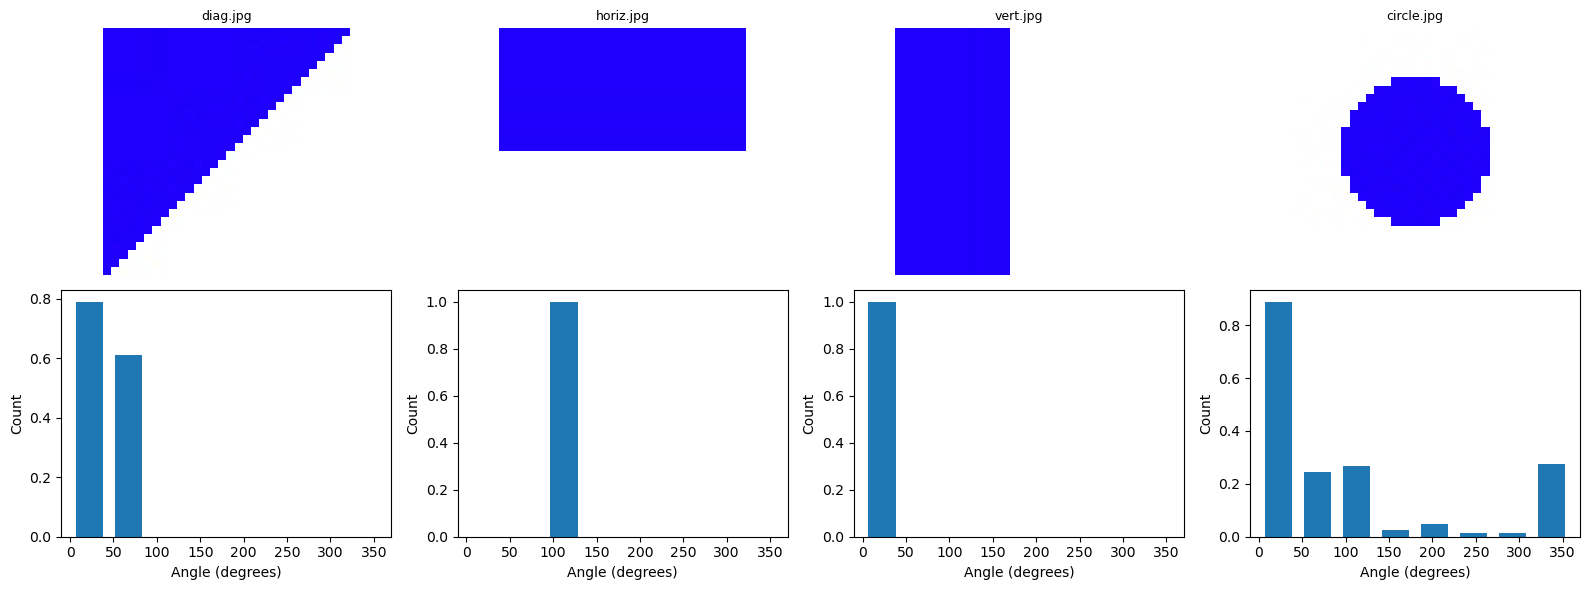

In [ ]:
import numpy as np
import cv2
import math
import matplotlib.pyplot as plt

###############################################################
#
# Write your own descriptor / Histogram of Oriented Gradients
#
###############################################################

def plot_histogram(ax, hist, bins):
    width = 0.7 * (bins[1] - bins[0])
    center = (bins[:-1] + bins[1:]) / 2
    ax.bar(center, hist, align='center', width=width)
    ax.set_xlim(-10, 370)           
    ax.set_xticks([0, 50, 100, 150, 200, 250, 300, 350])  
    ax.set_xlabel('Angle (degrees)')
    ax.set_ylabel('Count')

def compute_simple_hog(imgcolor, keypoints, axes_img, axes_hist):
    # convert color to gray image and extract feature in gray
    img = cv2.cvtColor(imgcolor, cv2.COLOR_BGR2GRAY)
    img = np.float32(img) 

    # compute x and y gradients (sobel kernel size 5)
    grad_x = cv2.Sobel(img, cv2.CV_32F, 1, 0, ksize=5)
    grad_y = cv2.Sobel(img, cv2.CV_32F, 0, 1, ksize=5)

    # compute magnitude and angle of the gradients
    magnitude = cv2.magnitude(grad_x, grad_y)
    angle = cv2.phase(grad_x, grad_y, angleInDegrees=True)

    angle = np.mod(angle, 360) 

    # go through all keypoints and compute feature vector
    descr = np.zeros((len(keypoints), 8), np.float32)
   
    for count, kp in enumerate(keypoints):
        
        # print kp.pt, kp.size
        print(kp.pt, kp.size)

        # extract angle in keypoint sub window
        half = kp.size // 2
        r0 = max(int(round(kp.pt[1] - half)), 0)
        r1 = min(int(round(kp.pt[1] + half + 1)), img.shape[0])
        c0 = max(int(round(kp.pt[0] - half)), 0)
        c1 = min(int(round(kp.pt[0] + half + 1)), img.shape[1])

        angle_window     = angle[r0:r1, c0:c1]
        magnitude_window = magnitude[r0:r1, c0:c1]
        

        valid_angles = angle_window[magnitude_window > 0]
        valid_magnitudes = magnitude_window[magnitude_window > 0]

        # create histogram of angle in subwindow BUT only where magnitude of gradients is non zero!
        hist, bins = np.histogram(valid_angles, bins=8, range=(0, 360), weights=valid_magnitudes)

        hist = hist.astype(np.float32)

        # normalize histogram
        if np.linalg.norm(hist) > 0:
            hist = hist / np.linalg.norm(hist)

        plot_histogram(axes_hist, hist, bins)
        descr[count] = hist

    axes_img.imshow(cv2.cvtColor(imgcolor, cv2.COLOR_BGR2RGB))
    axes_img.axis('off')

    return descr

images = ['./images/hog_test/diag.jpg',
          './images/hog_test/horiz.jpg',
          './images/hog_test/vert.jpg',
          './images/hog_test/circle.jpg']

# one figure with 2 rows x N columns
fig, axes = plt.subplots(2, len(images), figsize=(16, 6))

for i, img_path in enumerate(images):
    test = cv2.imread(img_path)
    if test is None:
        continue
    
    # Keypoint in der Bildmitte berechnen
    h, w = test.shape[:2]
    keypoints = [cv2.KeyPoint(w / 2.0, h / 2.0, 11)]  
    
    descriptor = compute_simple_hog(test, keypoints, axes[0, i], axes[1, i])
    axes[0, i].set_title(img_path.split('/')[-1], fontsize=9)

plt.tight_layout()
plt.savefig("hog_result.png", dpi=150)
plt.show()

graffiti.png DIFF: 0


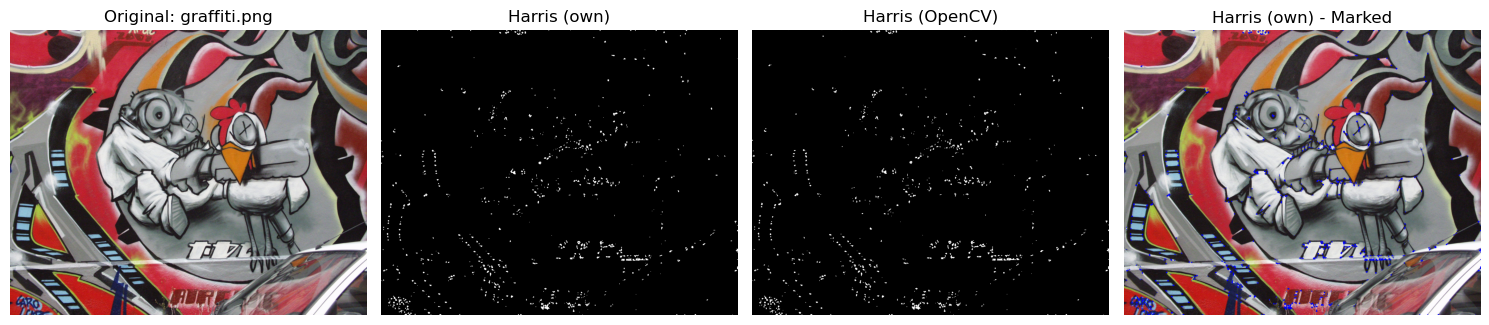

chessboard.png DIFF: 0


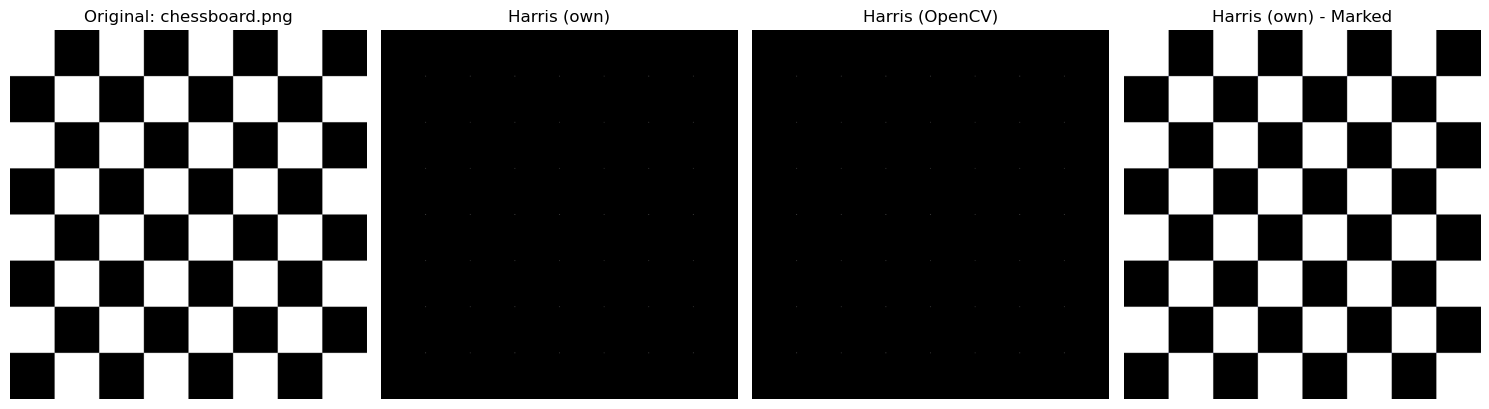

marker.jpg DIFF: 0


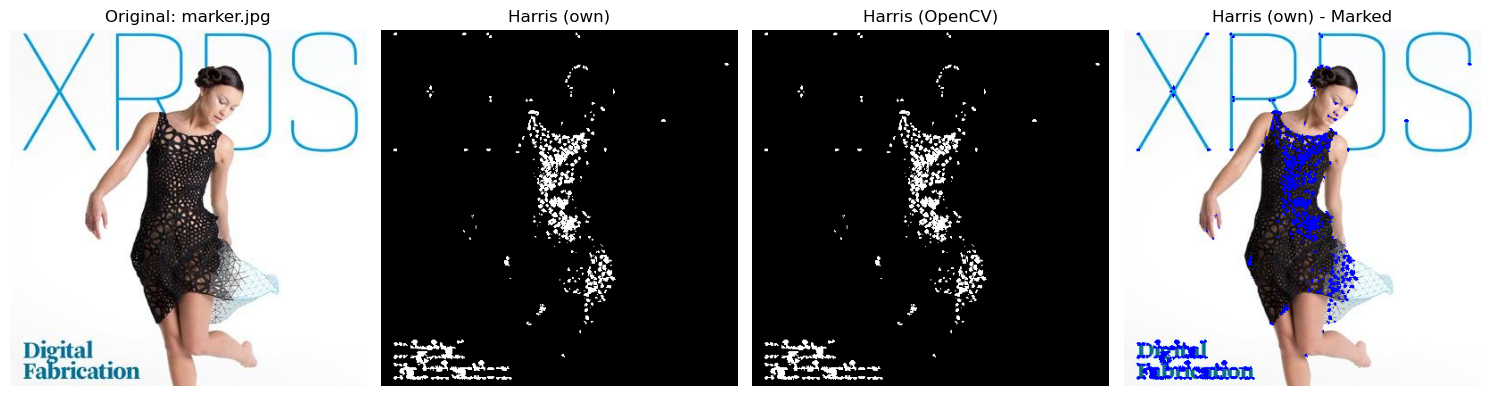

In [72]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_names = ["graffiti.png", "chessboard.png", "marker.jpg"]
base_dir = "./images"

sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
sobel_y = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]], dtype=np.float32)

k = 0.04
threshold = 0.01

for image_name in image_names:
    image_path = os.path.join(base_dir, image_name)
    img = cv2.imread(image_path)
    if img is None:
        print(f"Could not read image: {image_path}")
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = np.float32(gray)

    G_x = cv2.filter2D(gray, -1, sobel_x)
    G_y = cv2.filter2D(gray, -1, sobel_y)

    I_xx = G_x ** 2
    I_yy = G_y ** 2
    I_xy = G_x * G_y

    sumIxx = cv2.filter2D(I_xx, -1, np.ones((3, 3)))
    sumIyy = cv2.filter2D(I_yy, -1, np.ones((3, 3)))
    sumIxy = cv2.filter2D(I_xy, -1, np.ones((3, 3)))

    det_M = sumIxx * sumIyy - sumIxy ** 2
    trace_M = sumIxx + sumIyy
    harris = det_M - k * (trace_M ** 2)

    harris_cv = cv2.cornerHarris(gray, 3, 3, k)

    harris_cv_thres = np.zeros(harris_cv.shape, dtype=np.uint8)
    harris_cv_thres[harris_cv > threshold * harris_cv.max()] = 255

    harris_thres = np.zeros(harris.shape, dtype=np.uint8)
    harris_thres[harris > threshold * harris.max()] = 255

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    marked = img_rgb.copy()
    marked[harris > threshold * harris.max()] = [0, 0 , 255]

    print("====================================")
    print(f"{image_name} DIFF:", np.sum(np.abs(harris_thres.astype(np.int32) - harris_cv_thres.astype(np.int32))))
    print("====================================")

    fig, axes = plt.subplots(1, 4, figsize=(15, 5))
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Original: {image_name}")
    axes[0].axis('off')

    axes[1].imshow(harris_thres, cmap='gray')
    axes[1].set_title('Harris (own)')
    axes[1].axis('off')

    axes[2].imshow(harris_cv_thres, cmap='gray')
    axes[2].set_title('Harris (OpenCV)')
    axes[2].axis('off')

    axes[3].imshow(marked)
    axes[3].set_title('Harris (own) - Marked')
    axes[3].axis('off')


    plt.tight_layout()
    out_name = f"Harris_comparison_{os.path.splitext(image_name)[0]}.png"
    plt.savefig(out_name)
    plt.show()
    plt.close(fig)